In [71]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster,cophenet
from sklearn.preprocessing import StandardScaler
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

### Estandarización y selección de columnas para cluster de productos

In [72]:
#Leyendo el dataset
resumen_productos = pd.read_csv('../data_clean/resumen_productos.csv')
resumen_productos.head(5)

,ID_Producto,Nombre_producto,Categoría,Precio_Unitario,Stock,Unidades_Vendidas,Venta_Total,Transacciones,%_Unidades,%_Venta,Cancelada,Completa,Pendiente
0,6,Asado,Carnicería,28.56,5137,299,8539.44,81,2.863710,8.282421,0,71,10
1,8,Milanesa,Carnicería,16.21,3140,320,5187.20,89,3.064841,5.031076,0,76,13
2,25,Pizza congelada,Congelados,15.45,1640,332,5129.40,86,3.179772,4.975016,1,79,6
3,4,Queso rallado,Lácteos,19.23,2099,259,4980.57,77,2.480605,4.830665,1,67,9
4,3,Queso cremoso,Lácteos,17.23,3167,268,4617.64,84,2.566804,4.478659,0,66,18


In [73]:
resumen_productos['Porc_Canceladas'] = resumen_productos['Cancelada']/resumen_productos['Transacciones'] *100
resumen_productos['Porc_Completadas'] = resumen_productos['Completa']/resumen_productos['Transacciones'] *100
resumen_productos['Porc_Pendientes'] = resumen_productos['Pendiente']/resumen_productos['Transacciones'] *100


resumen_productos['Porc_Unidades'] = resumen_productos['%_Unidades']/100
resumen_productos['Porc_Ventas'] = resumen_productos['%_Venta']/100

In [74]:
resumen_productos = resumen_productos.drop(columns=['Cancelada', 'Completa', 'Pendiente', '%_Unidades', '%_Venta'])

resumen_productos.head(5)

,ID_Producto,Nombre_producto,Categoría,Precio_Unitario,Stock,Unidades_Vendidas,Venta_Total,Transacciones,Porc_Canceladas,Porc_Completadas,Porc_Pendientes,Porc_Unidades,Porc_Ventas
0,6,Asado,Carnicería,28.56,5137,299,8539.44,81,0.000000,87.654321,12.345679,0.028637,0.082824
1,8,Milanesa,Carnicería,16.21,3140,320,5187.20,89,0.000000,85.393258,14.606742,0.030648,0.050311
2,25,Pizza congelada,Congelados,15.45,1640,332,5129.40,86,1.162791,91.860465,6.976744,0.031798,0.049750
3,4,Queso rallado,Lácteos,19.23,2099,259,4980.57,77,1.298701,87.012987,11.688312,0.024806,0.048307
4,3,Queso cremoso,Lácteos,17.23,3167,268,4617.64,84,0.000000,78.571429,21.428571,0.025668,0.044787


In [75]:
#Filtrando las posibles columnas a usar
interest_cols = ['Unidades_Vendidas', 'Venta_Total', 'Transacciones', 'Porc_Unidades', 'Porc_Ventas', 'Precio_Unitario', 'Porc_Canceladas', 'Porc_Completadas', 'Porc_Pendientes', 'Stock']
X_prod = resumen_productos[interest_cols]
X_prod = X_prod.rename(columns={'Categoría': 'Categoria'})
X_prod.head(5)

,Unidades_Vendidas,Venta_Total,Transacciones,Porc_Unidades,Porc_Ventas,Precio_Unitario,Porc_Canceladas,Porc_Completadas,Porc_Pendientes,Stock
0,299,8539.44,81,0.028637,0.082824,28.56,0.000000,87.654321,12.345679,5137
1,320,5187.20,89,0.030648,0.050311,16.21,0.000000,85.393258,14.606742,3140
2,332,5129.40,86,0.031798,0.049750,15.45,1.162791,91.860465,6.976744,1640
3,259,4980.57,77,0.024806,0.048307,19.23,1.298701,87.012987,11.688312,2099
4,268,4617.64,84,0.025668,0.044787,17.23,0.000000,78.571429,21.428571,3167


In [76]:
# Aplicando el StandardScaler a los datos 
scaler = StandardScaler()
X_scaled_values = scaler.fit_transform(X_prod)
X_prod_scaled = pd.DataFrame(X_scaled_values, columns=X_prod.columns)

X_prod_scaled.head(5)

,Unidades_Vendidas,Venta_Total,Transacciones,Porc_Unidades,Porc_Ventas,Precio_Unitario,Porc_Canceladas,Porc_Completadas,Porc_Pendientes,Stock
0,0.589461,3.640095,0.217133,0.589461,3.640095,3.392403,-0.425004,0.766728,-0.708987,1.746380
1,1.100200,1.545681,1.063395,1.100200,1.545681,1.154800,-0.425004,0.279457,-0.209220,0.002711
2,1.392051,1.509568,0.746046,1.392051,1.509568,1.017101,0.986195,1.673173,-1.895691,-1.307005
3,-0.383374,1.416582,-0.205998,-0.383374,1.416582,1.701971,1.151140,0.628517,-0.854286,-0.906232
4,-0.164486,1.189831,0.534481,-0.164486,1.189831,1.339606,-0.425004,-1.190681,1.298620,0.026286


In [77]:
correlation =  X_prod.corr()

fig = px.imshow(correlation, text_auto=".2f")
fig.update_layout(width = 1200, height = 1200)
fig.show()

Como se puede observar, existen diversas variables altamente correlacionadas entre sí, lo cual no es ideal para la agrupación de datos ya que genera redundancia. Adicionalmente, tras realizar diversas pruebas de validación, se obtuvieron mejores resultados de clusterización al limitar el modelo a las siguientes columnas:

- Porc_Completadas
- Precio_Unitario
- Unidades_Vendidas

In [78]:
used_cols = ['Porc_Completadas', 'Precio_Unitario', 'Unidades_Vendidas']

X_prod_scaled = X_prod_scaled[used_cols]

X_prod_scaled.head(5)

,Porc_Completadas,Precio_Unitario,Unidades_Vendidas
0,0.766728,3.392403,0.589461
1,0.279457,1.154800,1.100200
2,1.673173,1.017101,1.392051
3,0.628517,1.701971,-0.383374
4,-1.190681,1.339606,-0.164486


## Elección de K

In [79]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Definimos un rango de valores para 'eps' en lugar de 'k'.
# Nota: Si tus datos están escalados (StandardScaler), valores entre 0.1 y 2.0 suelen funcionar.
eps_values = np.linspace(0.1, 2.0, 20) 
min_samples_val = 5 # Valor común por defecto, puedes ajustarlo también

dbscan_scores = []

for eps in eps_values:
    # 1. Configuramos y entrenamos DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=min_samples_val)
    cluster_labels = dbscan.fit_predict(X_prod_scaled)
    
    # 2. Contamos clusters y ruido
    # El set de etiquetas únicas menos el -1 (si existe) nos da la cantidad real de clusters
    unique_labels = set(cluster_labels)
    n_clusters = len(unique_labels) - (1 if -1 in cluster_labels else 0)
    n_noise = list(cluster_labels).count(-1)
    
    # 3. Calculamos Silhouette Score
    # Silhouette requiere al menos 2 etiquetas distintas para calcularse.
    if len(unique_labels) > 1:
        score = silhouette_score(X_prod_scaled, cluster_labels)
    else:
        score = -1 # Asignamos un score bajo si no logró separar clusters válidos
    
    # 4. Guardamos los resultados (Sin inercia, porque no existe en DBSCAN)
    dbscan_scores.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'silhouette_score': score
    })

# Creamos el DataFrame resumen
summary_scores_dbscan = pd.DataFrame(dbscan_scores).set_index('eps')

# Filtramos para ver solo configuraciones útiles (donde encontró clusters)
print(summary_scores_dbscan[summary_scores_dbscan['n_clusters'] > 0])

     n_clusters  n_noise  silhouette_score
eps                                       
0.7           1       33         -0.047938
0.8           1       32         -0.050186
0.9           2       26         -0.061139
1.0           1       19          0.041490
1.1           1       12          0.169143
1.2           1        6          0.286535
1.3           1        5          0.278874
1.4           1        4          0.321238
1.5           1        1          0.386175
1.6           1        1          0.386175
1.7           1        1          0.386175
1.8           1        1          0.386175
1.9           1        1          0.386175
2.0           1        0         -1.000000


In [80]:
# Usando KMeans para determinar el numero de clusters

k_values = [i for i in range(2, 11)]
inertias = []
silhouette_scores_kmeans = []

for k in k_values:
    k_means = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = k_means.fit_predict(X_prod_scaled)
    inertias.append(k_means.inertia_)
    #print(k_means.labels_)
    silhouette_scores_kmeans.append({'silhouette_score': silhouette_score(X_prod_scaled, cluster_labels)})

summary_scores_kmeans = pd.DataFrame(silhouette_scores_kmeans, index=k_values)

summary_scores_kmeans

,silhouette_score
2,0.223107
3,0.205454
4,0.228401
5,0.179609
6,0.230572
7,0.254162
8,0.240409
9,0.214968
10,0.230520


In [81]:
#Gemini created the subplots

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('<b>Método del codo (Inercia)</b>', '<b>Silhouette Scores</b>')
)

fig.add_trace(go.Scatter(
    x=k_values,
    y=inertias,
    mode='lines+markers',
    name='Intercia (WCSS)',
    marker=dict(color='blue', size=10, line=dict(width=1, color='DarkSlateGrey')),
    line=dict(color='blue', width=2)
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=summary_scores_kmeans.index,
    y=summary_scores_kmeans['silhouette_score'],
    mode='lines+markers',
    name='Silhouette Score',
    marker=dict(color='green', size=10, line=dict(width=1, color='DarkSlateGrey')),
    line=dict(color='green', width=2)
), row=1, col=2)

fig.update_layout(
    title=dict(
        text='<b>K-Means Cluster Análisis</b>',
        x=0.5,
        font=dict(size=24, color='black')
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False, # The subplot titles are clear enough
    hovermode='x unified'
)


fig.update_xaxes(
    title_text='Número de clusters (k)',
    dtick=1, # Tick for every k-value
    gridcolor='rgba(200, 200, 200, 0.5)',
    zeroline=False,
    showline=True,
    linewidth=1,
    linecolor='black',
    row=1, col=1 
)
fig.update_yaxes(
    title_text='Inercia (WCSS)',
    gridcolor='rgba(200, 200, 200, 0.5)',
    zeroline=False,
    showline=True,
    linewidth=1,
    linecolor='black',
    row=1, col=1 
)

# 6. Update axes for Subplot 2 (Silhouette)
fig.update_xaxes(
    title_text='Número de clusters (k)',
    dtick=1,
    gridcolor='rgba(200, 200, 200, 0.5)',
    zeroline=False,
    showline=True,
    linewidth=1,
    linecolor='black',
    row=1, col=2
)
fig.update_yaxes(
    title_text='Silhouette Score',
    gridcolor='rgba(200, 200, 200, 0.5)',
    zeroline=False,
    showline=True,
    linewidth=1,
    linecolor='black',
    row=1, col=2
)

# Show the final combined figure
fig.show()

In [82]:
# Dendrogram
#compute linkage matrices for all four methods (deepseek intervention)
linkage_matrices = {}

linkage_matrices['ward'] = linkage(X_prod_scaled, method='ward')
print(f"{'ward'.capitalize()} linkage computed, Shape: {linkage_matrices['ward'].shape}")

linkage_matrices['ward'][:5].round(3)

Ward linkage computed, Shape: (37, 4)


array([[ 7.   , 11.   ,  0.239,  2.   ],
       [18.   , 24.   ,  0.393,  2.   ],
       [ 3.   ,  5.   ,  0.413,  2.   ],
       [34.   , 36.   ,  0.423,  2.   ],
       [25.   , 31.   ,  0.667,  2.   ]])

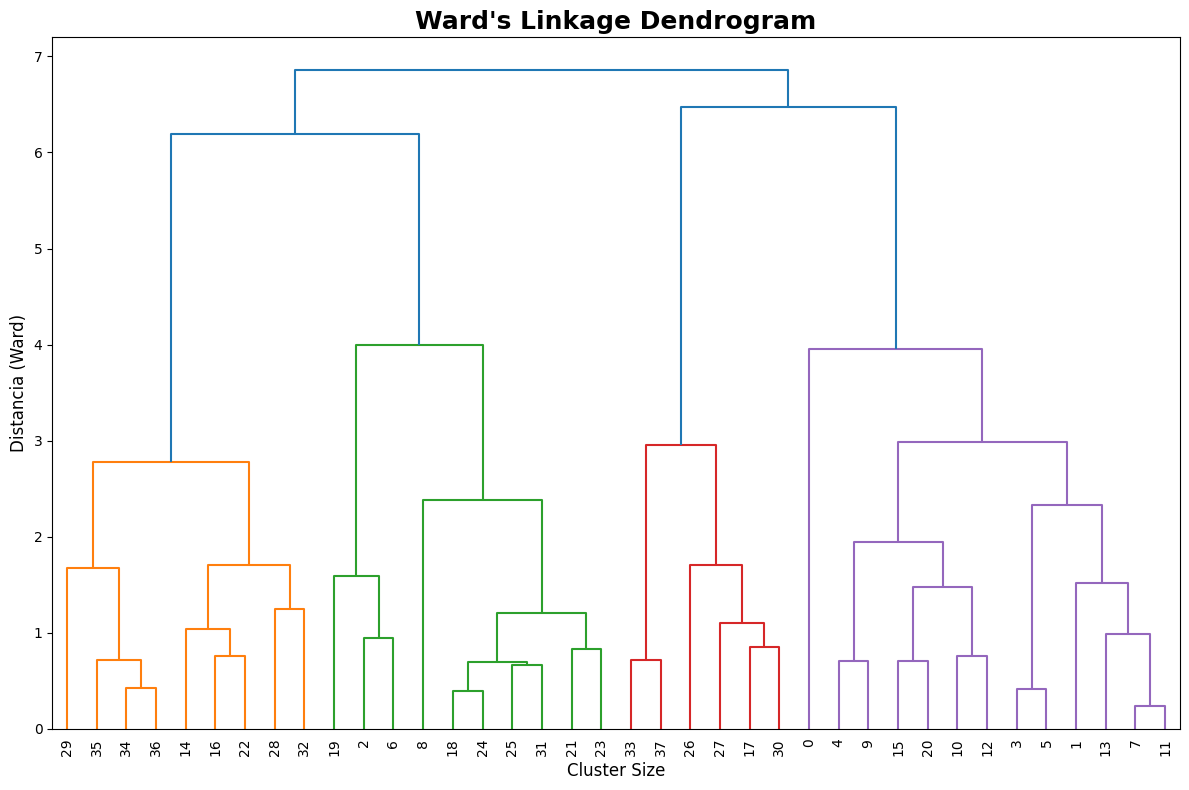

In [83]:
#Gemini was used to increase the quality of the plot

plt.figure(figsize=(12, 8))

ward_matrix = linkage_matrices['ward']

dendrogram(
    ward_matrix,
    truncate_mode='lastp',
    p=50,  # Show last 50 merges
    show_leaf_counts=True,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.title("Ward's Linkage Dendrogram", fontsize=18, fontweight='bold')
plt.xlabel('Cluster Size', fontsize=12)
plt.ylabel('Distancia (Ward)', fontsize=12)



plt.tight_layout()
plt.show()

In [84]:
selected_k = 4

k_means_model = KMeans(n_clusters=selected_k, random_state=42, n_init='auto')
k_means_model.fit(X_prod_scaled)

df_labels = resumen_productos.copy()
df_labels['label'] = k_means_model.labels_

cluster_counts = df_labels['label'].value_counts().sort_index()
cluster_percentages = df_labels['label'].value_counts(normalize=True).sort_index() * 100

cluster_summary = pd.DataFrame({
    'Cluster': cluster_counts.index,
    'Count': cluster_counts.values,
    'Percentage': cluster_percentages.values
})

print(cluster_summary.to_string())

   Cluster  Count  Percentage
0        0      9   23.684211
1        1     13   34.210526
2        2      5   13.157895
3        3     11   28.947368


In [90]:
cluster_means_original = df_labels.groupby('label')[used_cols].mean()

cluster_means_original

,Porc_Completadas,Precio_Unitario,Unidades_Vendidas
label,,,
0,86.608468,11.056667,240.333333
1,85.831884,6.166923,306.692308
2,87.567305,19.602000,291.200000
3,78.412720,8.735455,257.727273


In [92]:
# Heatmap (improved by Gemini)

scaler = StandardScaler()
scaled_means_for_color = scaler.fit_transform(cluster_means_original)

x_labels = [f'Cluster {i}' for i in cluster_means_original.index]
y_labels = cluster_means_original.columns
scaled_z_data = scaled_means_for_color.T  
original_text_data = cluster_means_original.T  

fig = go.Figure()

fig.add_trace(go.Heatmap(
    z=scaled_z_data,                   
    x=x_labels,                        
    y=y_labels,                        
    
    text=original_text_data,           
    texttemplate="%{text:.2f}",        
    
    colorscale='RdBu_r',             
    colorbar_title='Valor escalado' 
))

fig.update_layout(
    title_text='<b>Perfiles por cluster con medias originales y colores escalados</b>',
    title_x = 0.5,
    xaxis_title='Cluster',
    yaxis_title='Variable',
    # Ensure all variable names are visible
    yaxis={'tickmode': 'array', 'tickvals': y_labels, 'ticktext': y_labels},
    height=600
)

fig.show()

El valor final elegido es $k = 4$ , esto debido a que el análisis por el el método del codo deja de crecer en el intervalo (4-5), además de que el silluouete score no es malo en ese punto, pues se encuentra en un máximo local. 

Además de eso el análisis del Linkage Dendrogram muestra una recomendación de 4 clusters agrupados a una distancia suficiente para lograr una separación deseada. 

Finalmente la interpretación con 4 clusters es mejor ya que se está buscando una agrupación por tendencias de venta y esta logra un buen resultado agrupandose en los siguientes grupos: 

- **Cluster 0 (Productos Estándar)**: Tienen un precio intermedio (11.06), pero son los que menos se venden (240.33). Sin embargo, su tasa de completitud es buena (86.61%). No son problemáticos, pero tampoco destacan.

- **Cluster 1 (Motores de Volumen)**: Son los productos "gancho". Tienen el precio más bajo (6.17) pero compensan con la mayor cantidad de unidades vendidas (306.69). Su tasa de completitud es saludable.

- **Cluster 2 (Productos Estrella)**: Tienen el precio más alto (19.60) y aun así mantienen un volumen de ventas muy alto (291.20), casi alcanzando al líder de volumen. Además, tienen la mejor tasa de completitud (87.57%), lo que indica satisfacción del cliente o eficiencia logística.

- **Cluster 3 (Productos Problemáticos)**: Son baratos (8.74), se venden poco comparado con los líderes, pero lo más crítico es el 78.41% de completitud. Algo está fallando en el proceso de venta o entrega.